# Grafos: Teoría y Algoritmos

Guía completa sobre teoría de grafos, representaciones, recorridos y algoritmos clásicos.

## ¿Qué es un grafo?

Un **grafo** $G = (V, E)$ es una estructura formada por:
- $V$: conjunto de **vértices** (nodos)
- $E \subseteq V \times V$: conjunto de **aristas** (conexiones)

### Tipos de grafos

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| **No dirigido** | Aristas sin dirección: $(u,v) = (v,u)$ | Redes sociales (amistad) |
| **Dirigido** (dígrafo) | Aristas con dirección: $(u,v) \neq (v,u)$ | Twitter (seguir) |
| **Ponderado** | Aristas con peso $w(u,v)$ | Mapas (distancias) |
| **No ponderado** | Todas las aristas pesan igual | Relaciones binarias |
| **Cíclico** | Contiene al menos un ciclo | Dependencias circulares |
| **Acíclico** | Sin ciclos | DAG: tareas con prereqs |
| **Conexo** | Existe camino entre todo par de nodos | Red eléctrica |
| **Bipartito** | Se puede colorear con 2 colores | Matching (ofertas/demandas) |

### Terminología esencial

| Término | Definición |
|---------|------------|
| **Grado** de $v$ | Número de aristas incidentes a $v$ |
| **Camino** | Secuencia de vértices conectados por aristas |
| **Ciclo** | Camino que empieza y termina en el mismo vértice |
| **Componente conexa** | Subgrafo conexo maximal |
| **Árbol** | Grafo conexo y acíclico ($|E| = |V| - 1$) |

### Teoremas fundamentales

**Handshaking Lemma** (Lema del apretón de manos):

$$\sum_{v \in V} \deg(v) = 2|E|$$

**Euler**: Un grafo conexo tiene un circuito euleriano $\iff$ todo vértice tiene grado par.

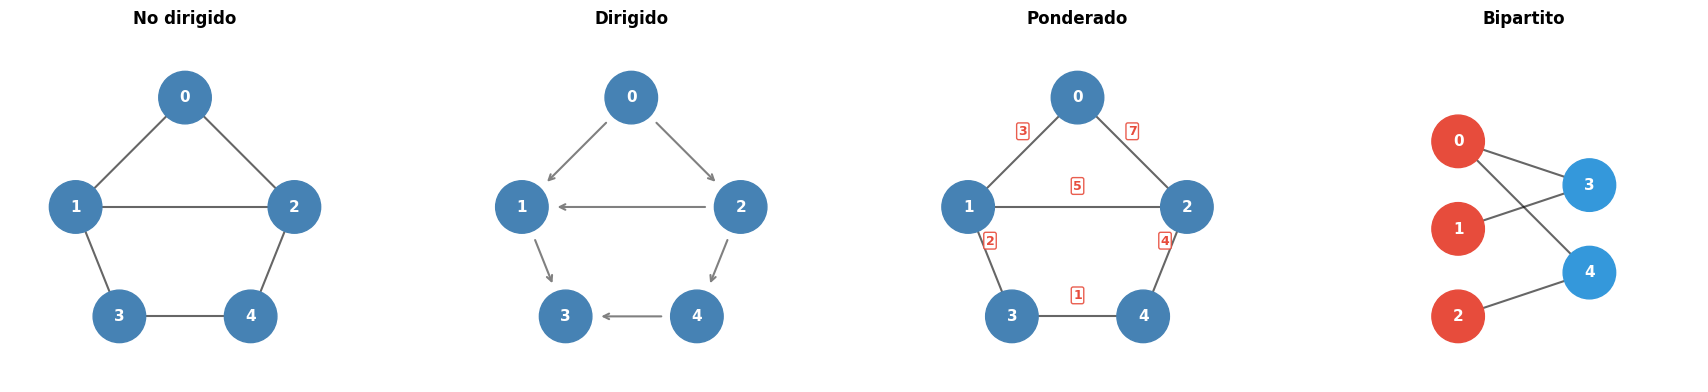

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualize different types of graphs
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

def draw_graph(ax, positions, edges, title, directed=False, weights=None, node_colors=None):
    if node_colors is None:
        node_colors = ['steelblue'] * len(positions)
    # Draw edges
    for i, (u, v) in enumerate(edges):
        xu, yu = positions[u]
        xv, yv = positions[v]
        if directed:
            dx, dy = xv - xu, yv - yu
            length = np.sqrt(dx**2 + dy**2)
            # Shorten arrow to not overlap node
            shrink = 0.15
            ax.annotate('', xy=(xv - dx*shrink/length, yv - dy*shrink/length),
                       xytext=(xu + dx*shrink/length, yu + dy*shrink/length),
                       arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
        else:
            ax.plot([xu, xv], [yu, yv], 'k-', linewidth=1.5, alpha=0.6, zorder=1)
        if weights and i < len(weights):
            mx, my = (xu + xv)/2, (yu + yv)/2
            ax.text(mx, my + 0.08, str(weights[i]), fontsize=9, ha='center',
                   fontweight='bold', color='#E74C3C',
                   bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='#E74C3C', alpha=0.9))
    # Draw nodes
    for i, (x, y) in enumerate(positions):
        circle = plt.Circle((x, y), 0.12, color=node_colors[i], zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(i), ha='center', va='center', fontsize=11,
               fontweight='bold', color='white', zorder=4)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Undirected
pos = [(0.5,1), (0,0.5), (1,0.5), (0.2,0), (0.8,0)]
edges_u = [(0,1),(0,2),(1,3),(2,4),(1,2),(3,4)]
draw_graph(axes[0], pos, edges_u, 'No dirigido')

# Directed
draw_graph(axes[1], pos, [(0,1),(0,2),(1,3),(2,4),(2,1),(4,3)], 'Dirigido', directed=True)

# Weighted
draw_graph(axes[2], pos, edges_u, 'Ponderado', weights=[3,7,2,4,5,1])

# Bipartite
pos_b = [(0.2,0.8),(0.2,0.4),(0.2,0),(0.8,0.6),(0.8,0.2)]
colors_b = ['#E74C3C','#E74C3C','#E74C3C','#3498DB','#3498DB']
draw_graph(axes[3], pos_b, [(0,3),(0,4),(1,3),(2,4)], 'Bipartito', node_colors=colors_b)

plt.tight_layout()
plt.show()

## Representaciones de grafos

### 1. Matriz de adyacencia

$$A[i][j] = \begin{cases} w(i,j) & \text{si } (i,j) \in E \\ 0 & \text{si no} \end{cases}$$

| Propiedad | Valor |
|-----------|-------|
| Espacio | $O(V^2)$ |
| Verificar arista | $O(1)$ |
| Vecinos de $v$ | $O(V)$ |
| Agregar arista | $O(1)$ |

### 2. Lista de adyacencia

Cada nodo almacena una lista de sus vecinos.

| Propiedad | Valor |
|-----------|-------|
| Espacio | $O(V + E)$ |
| Verificar arista | $O(\deg(v))$ |
| Vecinos de $v$ | $O(\deg(v))$ |
| Agregar arista | $O(1)$ |

### 3. Lista de aristas

Lista de tuplas $(u, v, w)$.

| Propiedad | Valor |
|-----------|-------|
| Espacio | $O(E)$ |
| Verificar arista | $O(E)$ |
| Todos los vecinos | $O(E)$ |
| Agregar arista | $O(1)$ |

### ¿Cuál usar?

| Grafo | Mejor representación |
|-------|---------------------|
| Denso ($E \approx V^2$) | Matriz de adyacencia |
| Disperso ($E \ll V^2$) | Lista de adyacencia |
| Algoritmos con aristas (Kruskal) | Lista de aristas |

=== Matriz de Adyacencia ===
    0  1  2  3  4
0: [np.int64(0), np.int64(4), np.int64(1), np.int64(0), np.int64(0)]
1: [np.int64(4), np.int64(0), np.int64(2), np.int64(5), np.int64(0)]
2: [np.int64(1), np.int64(2), np.int64(0), np.int64(8), np.int64(0)]
3: [np.int64(0), np.int64(5), np.int64(8), np.int64(0), np.int64(3)]
4: [np.int64(0), np.int64(0), np.int64(0), np.int64(3), np.int64(0)]

=== Lista de Adyacencia ===
0: [(1, 4), (2, 1)]
1: [(0, 4), (2, 2), (3, 5)]
2: [(0, 1), (1, 2), (3, 8)]
3: [(1, 5), (2, 8), (4, 3)]
4: [(3, 3)]

=== Lista de Aristas ===
(0, 1, peso=4)
(0, 2, peso=1)
(1, 2, peso=2)
(1, 3, peso=5)
(2, 3, peso=8)
(3, 4, peso=3)


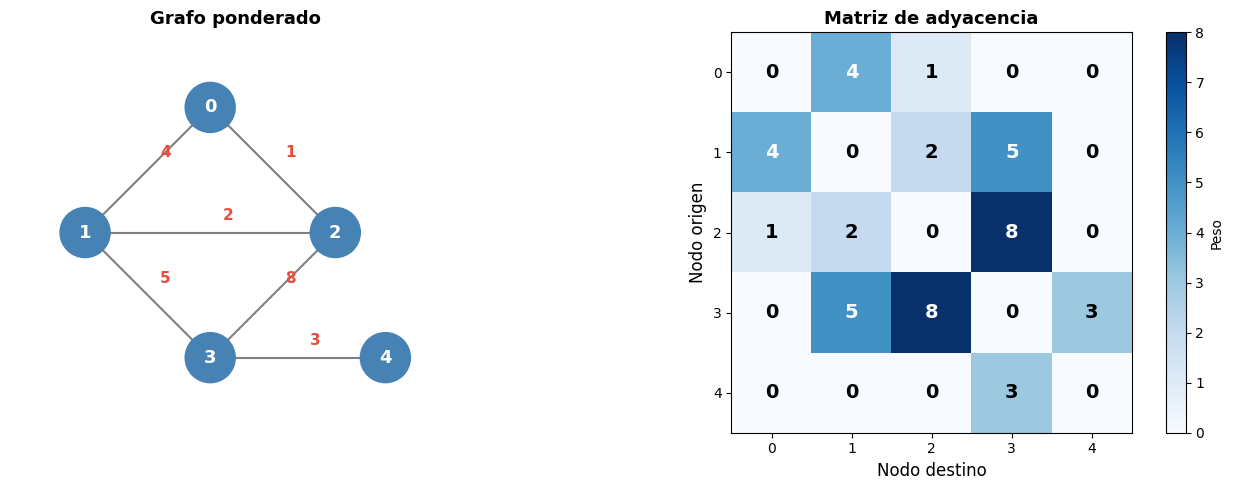

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Build all three representations
# Graph: 0--1(4), 0--2(1), 1--2(2), 1--3(5), 2--3(8), 3--4(3)
edges_list = [(0,1,4), (0,2,1), (1,2,2), (1,3,5), (2,3,8), (3,4,3)]
n_nodes = 5

# 1. Adjacency Matrix
adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)
for u, v, w in edges_list:
    adj_matrix[u][v] = w
    adj_matrix[v][u] = w

# 2. Adjacency List
adj_list = {i: [] for i in range(n_nodes)}
for u, v, w in edges_list:
    adj_list[u].append((v, w))
    adj_list[v].append((u, w))

print('=== Matriz de Adyacencia ===')
print('   ', '  '.join(str(i) for i in range(n_nodes)))
for i in range(n_nodes):
    print(f'{i}: {list(adj_matrix[i])}')

print('\n=== Lista de Adyacencia ===')
for node, neighbors in adj_list.items():
    print(f'{node}: {neighbors}')

print('\n=== Lista de Aristas ===')
for u, v, w in edges_list:
    print(f'({u}, {v}, peso={w})')

# Visualize the graph + matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Draw graph
pos = [(0.5, 1.0), (0.0, 0.5), (1.0, 0.5), (0.5, 0.0), (1.2, 0.0)]
ax = axes[0]
for u, v, w in edges_list:
    xu, yu = pos[u]; xv, yv = pos[v]
    ax.plot([xu, xv], [yu, yv], 'k-', linewidth=1.5, alpha=0.5, zorder=1)
    mx, my = (xu+xv)/2, (yu+yv)/2
    ax.text(mx+0.05, my+0.05, str(w), fontsize=11, color='#E74C3C', fontweight='bold')
for i, (x, y) in enumerate(pos):
    circle = plt.Circle((x, y), 0.1, color='steelblue', zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(i), ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=4)
ax.set_xlim(-0.3, 1.5); ax.set_ylim(-0.3, 1.3)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Grafo ponderado', fontsize=13, fontweight='bold')

# Draw adjacency matrix as heatmap
ax2 = axes[1]
im = ax2.imshow(adj_matrix, cmap='Blues', vmin=0)
for i in range(n_nodes):
    for j in range(n_nodes):
        color = 'white' if adj_matrix[i][j] > 3 else 'black'
        ax2.text(j, i, str(adj_matrix[i][j]), ha='center', va='center', fontsize=14, fontweight='bold', color=color)
ax2.set_xticks(range(n_nodes)); ax2.set_yticks(range(n_nodes))
ax2.set_xlabel('Nodo destino', fontsize=12); ax2.set_ylabel('Nodo origen', fontsize=12)
ax2.set_title('Matriz de adyacencia', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax2, label='Peso')

plt.tight_layout()
plt.show()

## BFS — Breadth-First Search (Búsqueda en anchura)

### Algoritmo

```
función BFS(grafo, inicio):
    cola = [inicio]
    visitado = {inicio}
    orden = []

    mientras cola no esté vacía:
        v = cola.popleft()
        orden.agregar(v)
        para cada vecino u de v:
            si u no está en visitado:
                visitado.agregar(u)
                cola.agregar(u)
    retornar orden
```

### Propiedades

| Propiedad | Valor |
|-----------|-------|
| Tiempo | $O(V + E)$ |
| Espacio | $O(V)$ |
| Encuentra | Camino más corto (no ponderado) |
| Estructura | Cola (FIFO) |

### Aplicaciones
- Camino más corto en grafos no ponderados
- Nivel/distancia desde un nodo
- Verificar si un grafo es bipartito
- Componentes conexas
- Web crawling

In [3]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Define a graph for BFS/DFS demos
graph = {
    0: [1, 2],
    1: [0, 3, 4],
    2: [0, 4, 5],
    3: [1, 6],
    4: [1, 2, 6],
    5: [2, 7],
    6: [3, 4, 7],
    7: [5, 6]
}

positions = {
    0: (1, 3), 1: (0, 2), 2: (2, 2),
    3: (-0.5, 1), 4: (1, 1), 5: (2.5, 1),
    6: (0.5, 0), 7: (2, 0)
}

def bfs_trace(graph, start):
    queue = deque([start])
    visited = {start}
    frames = [{'visited': set(), 'queue': [start], 'current': None, 'order': [], 'edges': []}]
    order = []
    edges_used = []
    while queue:
        v = queue.popleft()
        order.append(v)
        frames.append({'visited': set(visited), 'queue': list(queue), 'current': v,
                       'order': list(order), 'edges': list(edges_used)})
        for u in graph[v]:
            if u not in visited:
                visited.add(u)
                queue.append(u)
                edges_used.append((v, u))
                frames.append({'visited': set(visited), 'queue': list(queue), 'current': v,
                               'order': list(order), 'edges': list(edges_used)})
    return frames

bfs_frames = bfs_trace(graph, 0)

fig, ax = plt.subplots(figsize=(10, 7))

def draw_frame(frame_idx):
    ax.clear()
    f = bfs_frames[frame_idx]
    # Draw all edges
    for node, neighbors in graph.items():
        for nb in neighbors:
            if nb > node:
                x1, y1 = positions[node]; x2, y2 = positions[nb]
                ax.plot([x1,x2], [y1,y2], 'k-', linewidth=1, alpha=0.2, zorder=1)
    # Draw BFS tree edges
    for u, v in f['edges']:
        x1, y1 = positions[u]; x2, y2 = positions[v]
        ax.plot([x1,x2], [y1,y2], color='#E74C3C', linewidth=3, alpha=0.7, zorder=2)
    # Draw nodes
    for node, (x, y) in positions.items():
        if node == f['current']:
            color = '#FFA500'
        elif node in f['visited']:
            color = '#2ECC71'
        elif node in f['queue']:
            color = '#3498DB'
        else:
            color = '#BDC3C7'
        circle = plt.Circle((x, y), 0.25, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center', fontsize=15,
               fontweight='bold', color='white', zorder=4)
    # Info
    ax.text(0.5, -0.8, f'Cola: {f["queue"]}', fontsize=12, ha='center',
           bbox=dict(boxstyle='round', facecolor='#D6EAF8', alpha=0.8))
    ax.text(0.5, -1.2, f'Orden: {f["order"]}', fontsize=12, ha='center',
           bbox=dict(boxstyle='round', facecolor='#D5F5E3', alpha=0.8))
    ax.set_xlim(-1.2, 3.2); ax.set_ylim(-1.8, 3.8)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'BFS — Paso {frame_idx}/{len(bfs_frames)-1}', fontsize=14, fontweight='bold')
    # Legend
    ax.text(2.8, 3.5, 'Actual', fontsize=10, color='#FFA500', fontweight='bold')
    ax.text(2.8, 3.2, 'Visitado', fontsize=10, color='#2ECC71', fontweight='bold')
    ax.text(2.8, 2.9, 'En cola', fontsize=10, color='#3498DB', fontweight='bold')
    return []

anim = FuncAnimation(fig, draw_frame, frames=len(bfs_frames), interval=800, blit=False)
plt.close()
HTML(anim.to_jshtml())

## DFS — Depth-First Search (Búsqueda en profundidad)

### Algoritmo

```
función DFS(grafo, inicio):
    pila = [inicio]
    visitado = set()
    orden = []

    mientras pila no esté vacía:
        v = pila.pop()
        si v no está en visitado:
            visitado.agregar(v)
            orden.agregar(v)
            para cada vecino u de v (en reversa):
                si u no está en visitado:
                    pila.agregar(u)
    retornar orden
```

### Versión recursiva

```
función DFS_Recursivo(grafo, v, visitado):
    visitado.agregar(v)
    para cada vecino u de v:
        si u no está en visitado:
            DFS_Recursivo(grafo, u, visitado)
```

### Propiedades

| Propiedad | Valor |
|-----------|-------|
| Tiempo | $O(V + E)$ |
| Espacio | $O(V)$ |
| Estructura | Pila (LIFO) / recursión |

### Aplicaciones
- Detección de ciclos
- Orden topológico
- Componentes fuertemente conexas (Tarjan, Kosaraju)
- Resolución de laberintos
- Backtracking

In [4]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def dfs_trace(graph, start):
    stack = [start]
    visited = set()
    frames = [{'visited': set(), 'stack': [start], 'current': None, 'order': [], 'edges': []}]
    order = []
    edges_used = []
    parent = {}
    while stack:
        v = stack.pop()
        if v in visited:
            continue
        visited.add(v)
        order.append(v)
        if v in parent:
            edges_used.append((parent[v], v))
        frames.append({'visited': set(visited), 'stack': list(stack), 'current': v,
                       'order': list(order), 'edges': list(edges_used)})
        for u in reversed(graph[v]):
            if u not in visited:
                stack.append(u)
                parent[u] = v
        frames.append({'visited': set(visited), 'stack': list(stack), 'current': v,
                       'order': list(order), 'edges': list(edges_used)})
    return frames

dfs_frames = dfs_trace(graph, 0)

fig, ax = plt.subplots(figsize=(10, 7))

def draw_dfs_frame(frame_idx):
    ax.clear()
    f = dfs_frames[frame_idx]
    for node, neighbors in graph.items():
        for nb in neighbors:
            if nb > node:
                x1, y1 = positions[node]; x2, y2 = positions[nb]
                ax.plot([x1,x2], [y1,y2], 'k-', linewidth=1, alpha=0.2, zorder=1)
    for u, v in f['edges']:
        x1, y1 = positions[u]; x2, y2 = positions[v]
        ax.plot([x1,x2], [y1,y2], color='#9B59B6', linewidth=3, alpha=0.7, zorder=2)
    for node, (x, y) in positions.items():
        if node == f['current']:
            color = '#FFA500'
        elif node in f['visited']:
            color = '#9B59B6'
        elif node in f['stack']:
            color = '#3498DB'
        else:
            color = '#BDC3C7'
        circle = plt.Circle((x, y), 0.25, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center', fontsize=15,
               fontweight='bold', color='white', zorder=4)
    ax.text(0.5, -0.8, f'Pila: {f["stack"]}', fontsize=12, ha='center',
           bbox=dict(boxstyle='round', facecolor='#E8DAEF', alpha=0.8))
    ax.text(0.5, -1.2, f'Orden: {f["order"]}', fontsize=12, ha='center',
           bbox=dict(boxstyle='round', facecolor='#D5F5E3', alpha=0.8))
    ax.set_xlim(-1.2, 3.2); ax.set_ylim(-1.8, 3.8)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'DFS — Paso {frame_idx}/{len(dfs_frames)-1}', fontsize=14, fontweight='bold')
    ax.text(2.8, 3.5, 'Actual', fontsize=10, color='#FFA500', fontweight='bold')
    ax.text(2.8, 3.2, 'Visitado', fontsize=10, color='#9B59B6', fontweight='bold')
    ax.text(2.8, 2.9, 'En pila', fontsize=10, color='#3498DB', fontweight='bold')
    return []

anim = FuncAnimation(fig, draw_dfs_frame, frames=len(dfs_frames), interval=800, blit=False)
plt.close()
HTML(anim.to_jshtml())

### BFS vs DFS: Comparación visual

| Propiedad | BFS | DFS |
|-----------|-----|-----|
| Estructura | Cola (FIFO) | Pila (LIFO) |
| Exploración | Nivel por nivel | Rama completa |
| Camino más corto | Sí (no ponderado) | No |
| Memoria | $O(V)$ (puede ser ancho) | $O(V)$ (profundidad) |
| Detección de ciclos | Sí | Sí |
| Orden topológico | No directamente | Sí |

## Algoritmo de Dijkstra

Encuentra el **camino más corto** desde un nodo fuente a todos los demás en un grafo **ponderado con pesos no negativos**.

### Algoritmo

```
función Dijkstra(grafo, inicio):
    dist = {v: infinito para todo v}
    dist[inicio] = 0
    prev = {}
    heap = [(0, inicio)]    # (distancia, nodo)

    mientras heap no esté vacío:
        d, u = extraer_mínimo(heap)
        si d > dist[u]: continuar  # ya procesado
        para cada vecino (v, peso) de u:
            si dist[u] + peso < dist[v]:
                dist[v] = dist[u] + peso
                prev[v] = u
                insertar(heap, (dist[v], v))
    retornar dist, prev
```

### Complejidad

| Implementación | Tiempo |
|----------------|--------|
| Arreglo simple | $O(V^2)$ |
| Binary heap | $O((V + E) \log V)$ |
| Fibonacci heap | $O(V \log V + E)$ |

### Limitación

> **No funciona con pesos negativos.** Para eso se usa Bellman-Ford.

In [5]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Weighted graph for Dijkstra
w_graph = {
    0: [(1, 4), (2, 1)],
    1: [(0, 4), (2, 2), (3, 5)],
    2: [(0, 1), (1, 2), (3, 8), (4, 10)],
    3: [(1, 5), (2, 8), (4, 2), (5, 6)],
    4: [(2, 10), (3, 2), (5, 3)],
    5: [(3, 6), (4, 3)]
}

w_pos = {0:(0, 1), 1:(1, 2), 2:(1, 0), 3:(2, 1.5), 4:(2, 0), 5:(3, 0.8)}

def dijkstra_trace(graph, start):
    dist = {v: float('inf') for v in graph}
    dist[start] = 0
    prev = {}
    heap = [(0, start)]
    processed = set()
    frames = []
    frames.append({'dist': dict(dist), 'processed': set(), 'current': None, 'prev': dict(prev)})

    while heap:
        d, u = heapq.heappop(heap)
        if u in processed:
            continue
        processed.add(u)
        frames.append({'dist': dict(dist), 'processed': set(processed), 'current': u, 'prev': dict(prev)})

        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                heapq.heappush(heap, (dist[v], v))
        frames.append({'dist': dict(dist), 'processed': set(processed), 'current': u, 'prev': dict(prev)})

    return frames

dij_frames = dijkstra_trace(w_graph, 0)

fig, ax = plt.subplots(figsize=(12, 7))

def draw_dijkstra(frame_idx):
    ax.clear()
    f = dij_frames[frame_idx]
    # Draw edges
    drawn = set()
    for u in w_graph:
        for v, w in w_graph[u]:
            if (min(u,v), max(u,v)) not in drawn:
                drawn.add((min(u,v), max(u,v)))
                x1, y1 = w_pos[u]; x2, y2 = w_pos[v]
                # Check if this edge is in shortest path tree
                in_tree = (v in f['prev'] and f['prev'][v] == u) or (u in f['prev'] and f['prev'][u] == v)
                lw = 3 if in_tree else 1
                color = '#E74C3C' if in_tree else 'gray'
                alpha = 0.8 if in_tree else 0.3
                ax.plot([x1,x2], [y1,y2], color=color, linewidth=lw, alpha=alpha, zorder=1)
                mx, my = (x1+x2)/2, (y1+y2)/2
                ax.text(mx, my+0.1, str(w), fontsize=10, ha='center', color='gray',
                       bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.8))
    # Draw nodes
    for node, (x, y) in w_pos.items():
        if node == f['current']:
            color = '#FFA500'
        elif node in f['processed']:
            color = '#2ECC71'
        else:
            color = '#BDC3C7'
        circle = plt.Circle((x, y), 0.18, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
        d = f['dist'][node]
        d_str = str(d) if d != float('inf') else 'inf'
        ax.text(x, y-0.3, f'd={d_str}', ha='center', fontsize=10, fontweight='bold',
               color='#2C3E50', bbox=dict(boxstyle='round,pad=0.2', facecolor='#FDEBD0', alpha=0.9))
    ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.6, 2.7)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'Dijkstra — Paso {frame_idx}/{len(dij_frames)-1}', fontsize=14, fontweight='bold')
    return []

anim = FuncAnimation(fig, draw_dijkstra, frames=len(dij_frames), interval=1200, blit=False)
plt.close()
HTML(anim.to_jshtml())

## Algoritmo de Bellman-Ford

Encuentra caminos más cortos desde una fuente, soportando **pesos negativos** y detectando **ciclos negativos**.

### Algoritmo

```
función BellmanFord(vértices, aristas, inicio):
    dist = {v: infinito para todo v}
    dist[inicio] = 0

    // Relajar todas las aristas V-1 veces
    para i = 1 hasta |V|-1:
        para cada arista (u, v, peso):
            si dist[u] + peso < dist[v]:
                dist[v] = dist[u] + peso

    // Detectar ciclos negativos
    para cada arista (u, v, peso):
        si dist[u] + peso < dist[v]:
            ERROR: "Ciclo negativo detectado"

    retornar dist
```

### Complejidad

| Operación | Tiempo | Espacio |
|-----------|--------|--------|
| Relajación | $O(V \cdot E)$ | $O(V)$ |

### ¿Por qué $V-1$ iteraciones?

Un camino más corto tiene a lo sumo $V-1$ aristas. En cada iteración se garantiza encontrar al menos una arista más del camino óptimo.

### Dijkstra vs Bellman-Ford

| Propiedad | Dijkstra | Bellman-Ford |
|-----------|----------|-------------|
| Pesos negativos | No | Sí |
| Ciclos negativos | No detecta | Sí detecta |
| Complejidad | $O((V+E)\log V)$ | $O(VE)$ |
| Más rápido para | Grafos dispersos | Grafos con pesos negativos |

Aristas: [(0, 1, 4), (0, 2, 1), (1, 3, 1), (2, 1, -2), (2, 3, 5), (3, 4, 3)]
Ciclo negativo: False

Iteraciones de relajación:
Iter |   d[0] |   d[1] |   d[2] |   d[3] |   d[4]
--------------------------------------------------
   0 |     0 |   inf |   inf |   inf |   inf
   1 |     0 |    -1 |     1 |     5 |     8
   2 |     0 |    -1 |     1 |     0 |     3
   3 |     0 |    -1 |     1 |     0 |     3

Distancias finales: [0, -1, 1, 0, 3]


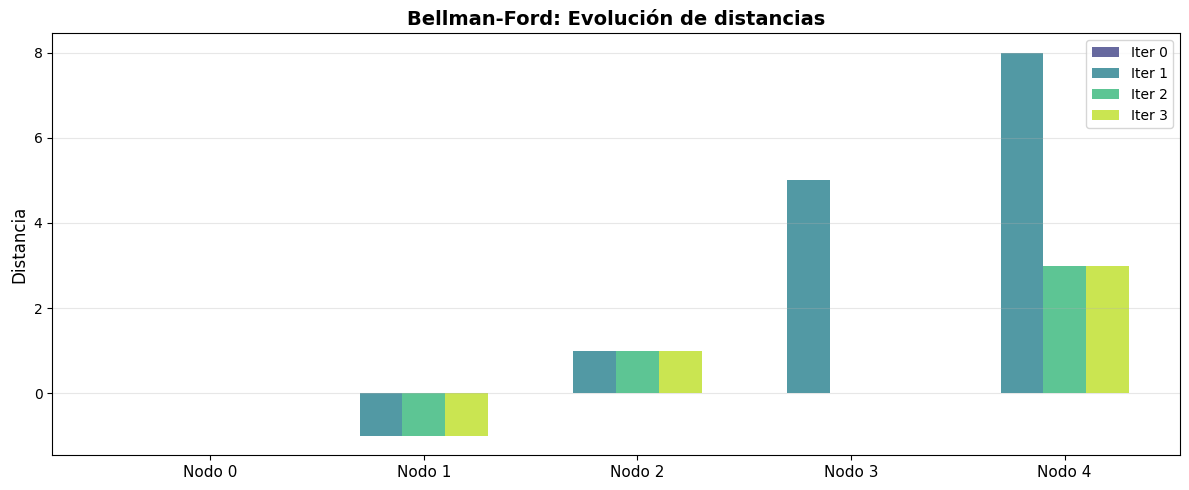

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def bellman_ford(n_vertices, edges, start):
    dist = [float('inf')] * n_vertices
    dist[start] = 0
    iterations = []
    iterations.append(list(dist))

    for i in range(n_vertices - 1):
        updated = False
        for u, v, w in edges:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                updated = True
        iterations.append(list(dist))
        if not updated:
            break

    # Check for negative cycles
    has_negative_cycle = False
    for u, v, w in edges:
        if dist[u] + w < dist[v]:
            has_negative_cycle = True
            break

    return dist, iterations, has_negative_cycle

# Example with some negative weights
edges_bf = [(0,1,4), (0,2,1), (1,3,1), (2,1,-2), (2,3,5), (3,4,3)]
n = 5
dist, iterations, neg_cycle = bellman_ford(n, edges_bf, 0)

print('Aristas:', edges_bf)
print(f'Ciclo negativo: {neg_cycle}')
print(f'\nIteraciones de relajación:')
print(f'{"Iter":>4} |', ' | '.join(f'  d[{i}]' for i in range(n)))
print('-' * 50)
for i, d in enumerate(iterations):
    vals = ' | '.join(f'{v:>5}' if v != float('inf') else '  inf' for v in d)
    print(f'{i:>4} | {vals}')

print(f'\nDistancias finales: {dist}')

# Visualize iterations
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(n)
width = 0.8 / len(iterations)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(iterations)))

for i, it in enumerate(iterations):
    vals = [v if v != float('inf') else 0 for v in it]
    bars = ax.bar(x + i * width, vals, width, label=f'Iter {i}', color=colors[i], alpha=0.8)

ax.set_xticks(x + width * len(iterations) / 2)
ax.set_xticklabels([f'Nodo {i}' for i in range(n)], fontsize=11)
ax.set_ylabel('Distancia', fontsize=12)
ax.set_title('Bellman-Ford: Evolución de distancias', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Árbol de Expansión Mínima (MST)

Un **MST** es un subconjunto de aristas que conecta todos los vértices con el **peso total mínimo**, sin formar ciclos.

### Propiedades

- Un MST tiene exactamente $|V| - 1$ aristas
- Si todos los pesos son distintos, el MST es único
- El MST minimiza el peso máximo de la arista (minimax path)

## Algoritmo de Kruskal

### Idea
Ordenar las aristas por peso y agregarlas si no forman ciclo (greedy). Usa **Union-Find** para detectar ciclos.

### Algoritmo

```
función Kruskal(V, aristas):
    Ordenar aristas por peso
    MST = []
    UF = UnionFind(V)

    para cada arista (u, v, peso) en orden:
        si UF.find(u) != UF.find(v):  // no forman ciclo
            MST.agregar( (u, v, peso) )
            UF.union(u, v)
        si |MST| == |V| - 1:
            break
    retornar MST
```

### Complejidad: $O(E \log E)$ (dominada por ordenar)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # path compression
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True

def kruskal_trace(n_vertices, edges):
    sorted_edges = sorted(edges, key=lambda x: x[2])
    uf = UnionFind(n_vertices)
    mst = []
    frames = [{'mst': [], 'considering': None, 'rejected': [], 'total_weight': 0}]
    rejected = []

    for u, v, w in sorted_edges:
        if uf.find(u) != uf.find(v):
            uf.union(u, v)
            mst.append((u, v, w))
            total_w = sum(e[2] for e in mst)
            frames.append({'mst': list(mst), 'considering': (u,v,w), 'rejected': list(rejected), 'total_weight': total_w})
        else:
            rejected.append((u, v, w))
            frames.append({'mst': list(mst), 'considering': (u,v,w), 'rejected': list(rejected),
                          'total_weight': sum(e[2] for e in mst)})
        if len(mst) == n_vertices - 1:
            break
    return frames, mst

# MST graph
mst_edges = [(0,1,4), (0,2,1), (1,2,2), (1,3,5), (2,3,8), (2,4,10), (3,4,2), (3,5,6), (4,5,3)]
mst_pos = {0:(0, 1.5), 1:(1, 2.5), 2:(1, 0.5), 3:(2, 1.5), 4:(2.5, 0), 5:(3, 1)}
mst_frames, mst_result = kruskal_trace(6, mst_edges)

fig, ax = plt.subplots(figsize=(12, 7))

def draw_kruskal(frame_idx):
    ax.clear()
    f = mst_frames[frame_idx]
    # All edges (light)
    for u, v, w in mst_edges:
        x1, y1 = mst_pos[u]; x2, y2 = mst_pos[v]
        ax.plot([x1,x2], [y1,y2], 'k-', linewidth=1, alpha=0.15, zorder=1)
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.1, str(w), fontsize=9, ha='center', color='gray', alpha=0.6)
    # Rejected edges
    for u, v, w in f['rejected']:
        x1, y1 = mst_pos[u]; x2, y2 = mst_pos[v]
        ax.plot([x1,x2], [y1,y2], color='#E74C3C', linewidth=2, alpha=0.3, linestyle='--', zorder=2)
    # MST edges
    for u, v, w in f['mst']:
        x1, y1 = mst_pos[u]; x2, y2 = mst_pos[v]
        ax.plot([x1,x2], [y1,y2], color='#2ECC71', linewidth=3.5, alpha=0.85, zorder=2)
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.15, str(w), fontsize=11, ha='center', color='#2ECC71', fontweight='bold')
    # Considering edge
    if f['considering']:
        u, v, w = f['considering']
        x1, y1 = mst_pos[u]; x2, y2 = mst_pos[v]
        in_mst = any(e[0]==u and e[1]==v for e in f['mst'])
        color = '#2ECC71' if in_mst else '#E74C3C'
        ax.plot([x1,x2], [y1,y2], color='#FFA500', linewidth=4, alpha=0.9, zorder=2)
    # Nodes
    for node, (x, y) in mst_pos.items():
        circle = plt.Circle((x, y), 0.18, color='steelblue', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
    ax.set_xlim(-0.5, 3.7); ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal'); ax.axis('off')
    status = f'Peso total: {f["total_weight"]}'
    if f['considering']:
        u,v,w = f['considering']
        in_mst = any(e[0]==u and e[1]==v for e in f['mst'])
        action = 'Aceptada' if in_mst else 'Rechazada (ciclo)'
        status += f' | Arista ({u},{v}) peso={w}: {action}'
    ax.set_title(f'Kruskal MST — Paso {frame_idx}/{len(mst_frames)-1}', fontsize=14, fontweight='bold')
    ax.text(1.5, -0.3, status, ha='center', fontsize=12,
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    return []

anim = FuncAnimation(fig, draw_kruskal, frames=len(mst_frames), interval=1500, blit=False)
plt.close()
HTML(anim.to_jshtml())

## Algoritmo de Prim

### Idea
Empezar desde un nodo y expandir el árbol agregando la arista de **menor peso** que conecte un nodo del árbol con uno fuera.

### Algoritmo

```
función Prim(grafo, inicio):
    en_MST = {inicio}
    MST = []
    heap = [(peso, inicio, vecino) para cada (vecino, peso) de inicio]

    mientras |en_MST| < |V|:
        peso, u, v = extraer_mínimo(heap)
        si v ya está en_MST: continuar
        en_MST.agregar(v)
        MST.agregar( (u, v, peso) )
        para cada (w, p) vecino de v:
            si w no está en_MST:
                insertar(heap, (p, v, w))
    retornar MST
```

### Complejidad: $O((V + E) \log V)$ con binary heap

### Kruskal vs Prim

| Propiedad | Kruskal | Prim |
|-----------|---------|------|
| Enfoque | Aristas globales | Crece desde un nodo |
| Estructura | Union-Find | Min-Heap |
| Mejor para | Grafos dispersos | Grafos densos |
| Complejidad | $O(E \log E)$ | $O((V+E) \log V)$ |

MST (Prim):
  0 -- 2 (peso 1)
  2 -- 1 (peso 2)
  1 -- 3 (peso 5)
  3 -- 4 (peso 2)
  4 -- 5 (peso 3)
Peso total: 13


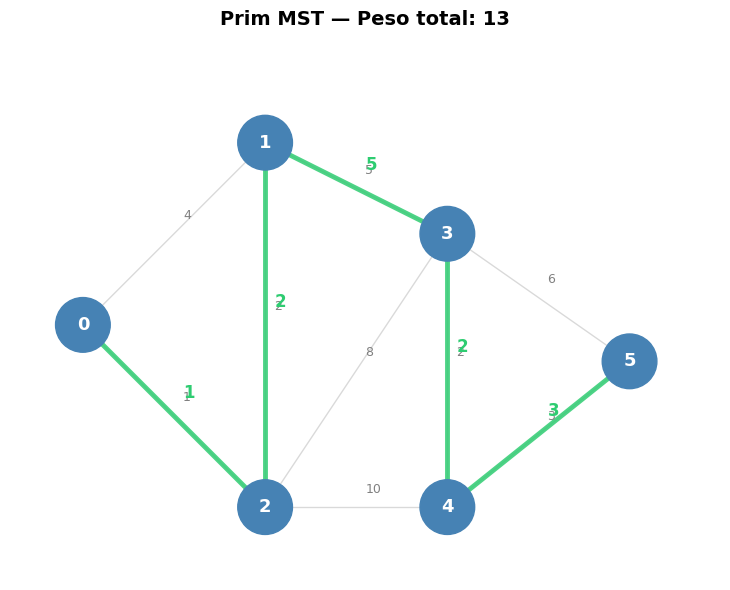

In [8]:
import heapq
import numpy as np
import matplotlib.pyplot as plt

def prim(graph, start=0):
    in_mst = {start}
    mst = []
    heap = []
    for v, w in graph[start]:
        heapq.heappush(heap, (w, start, v))

    while heap and len(in_mst) < len(graph):
        w, u, v = heapq.heappop(heap)
        if v in in_mst:
            continue
        in_mst.add(v)
        mst.append((u, v, w))
        for nb, wt in graph[v]:
            if nb not in in_mst:
                heapq.heappush(heap, (wt, v, nb))
    return mst

# Use same graph
prim_graph = {
    0: [(1,4), (2,1)],
    1: [(0,4), (2,2), (3,5)],
    2: [(0,1), (1,2), (3,8), (4,10)],
    3: [(1,5), (2,8), (4,2), (5,6)],
    4: [(2,10), (3,2), (5,3)],
    5: [(3,6), (4,3)]
}

mst_prim = prim(prim_graph, 0)
total_weight = sum(w for _,_,w in mst_prim)

print('MST (Prim):')
for u, v, w in mst_prim:
    print(f'  {u} -- {v} (peso {w})')
print(f'Peso total: {total_weight}')

# Visualize Prim result
fig, ax = plt.subplots(figsize=(10, 6))
prim_pos = {0:(0, 1), 1:(1, 2), 2:(1, 0), 3:(2, 1.5), 4:(2, 0), 5:(3, 0.8)}

# All edges faint
all_edges_drawn = set()
for u in prim_graph:
    for v, w in prim_graph[u]:
        key = (min(u,v), max(u,v))
        if key not in all_edges_drawn:
            all_edges_drawn.add(key)
            x1, y1 = prim_pos[u]; x2, y2 = prim_pos[v]
            ax.plot([x1,x2], [y1,y2], 'k-', linewidth=1, alpha=0.15)
            mx, my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx+0.05, my+0.08, str(w), fontsize=9, color='gray')

# MST edges bold
for u, v, w in mst_prim:
    x1, y1 = prim_pos[u]; x2, y2 = prim_pos[v]
    ax.plot([x1,x2], [y1,y2], color='#2ECC71', linewidth=3.5, alpha=0.85)
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx+0.05, my+0.1, str(w), fontsize=12, color='#2ECC71', fontweight='bold')

for node, (x, y) in prim_pos.items():
    circle = plt.Circle((x, y), 0.15, color='steelblue', zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(node), ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=4)

ax.set_xlim(-0.4, 3.5); ax.set_ylim(-0.4, 2.6)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Prim MST — Peso total: {total_weight}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Orden Topológico

Un **orden topológico** de un DAG (grafo dirigido acíclico) es una ordenación lineal de los vértices tal que para toda arista $(u, v)$, $u$ aparece antes que $v$.

### Aplicaciones
- Compilación (dependencias entre módulos)
- Planificación de tareas con prerequisitos
- Resolución de dependencias (npm, pip)
- Scheduling de cursos universitarios

### Algoritmo (Kahn — BFS)

```
función TopSort_Kahn(grafo):
    grado_entrada = calcular grados de entrada
    cola = [v donde grado_entrada[v] == 0]
    orden = []

    mientras cola no esté vacía:
        v = cola.popleft()
        orden.agregar(v)
        para cada vecino u de v:
            grado_entrada[u] -= 1
            si grado_entrada[u] == 0:
                cola.agregar(u)

    si |orden| != |V|:
        ERROR: "Ciclo detectado"
    retornar orden
```

### Complejidad: $O(V + E)$

Orden topológico de cursos:
  Semestre 1: Cálculo I
  Semestre 2: Programación
  Semestre 3: Cálculo II
  Semestre 4: Álgebra
  Semestre 5: Estructuras Datos
  Semestre 6: Álgebra Lineal
  Semestre 7: Algoritmos
  Semestre 8: Ecuaciones Dif.
  Semestre 9: Estadística
  Semestre 10: ML


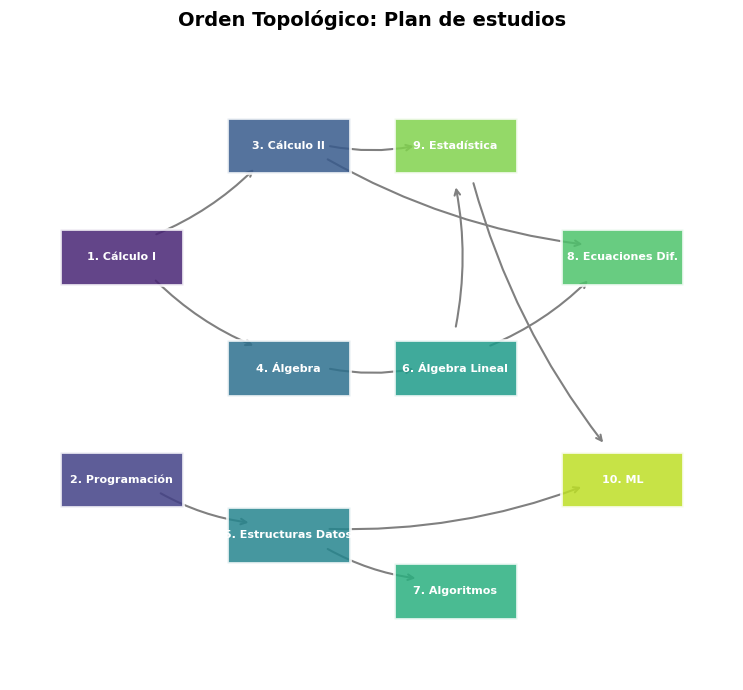

In [10]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

def topological_sort(graph):
    # Calculate in-degrees
    in_degree = {v: 0 for v in graph}
    for v in graph:
        for u in graph[v]:
            in_degree[u] = in_degree.get(u, 0) + 1

    queue = deque([v for v in graph if in_degree[v] == 0])
    order = []
    steps = []

    while queue:
        v = queue.popleft()
        order.append(v)
        steps.append({'node': v, 'order': list(order), 'queue': list(queue)})
        for u in graph[v]:
            in_degree[u] -= 1
            if in_degree[u] == 0:
                queue.append(u)

    return order, steps

# DAG: Course prerequisites
course_dag = {
    'Cálculo I': ['Cálculo II', 'Álgebra'],
    'Cálculo II': ['Estadística', 'Ecuaciones Dif.'],
    'Álgebra': ['Álgebra Lineal'],
    'Álgebra Lineal': ['Ecuaciones Dif.', 'Estadística'],
    'Estadística': ['ML'],
    'Ecuaciones Dif.': [],
    'Programación': ['Estructuras Datos'],
    'Estructuras Datos': ['Algoritmos', 'ML'],
    'Algoritmos': [],
    'ML': []
}

order, steps = topological_sort(course_dag)
print('Orden topológico de cursos:')
for i, course in enumerate(order):
    print(f'  Semestre {i+1}: {course}')

# Visualize DAG
fig, ax = plt.subplots(figsize=(14, 7))

dag_pos = {
    'Cálculo I': (0, 2), 'Cálculo II': (1.5, 3), 'Álgebra': (1.5, 1),
    'Álgebra Lineal': (3, 1), 'Estadística': (3, 3), 'Ecuaciones Dif.': (4.5, 2),
    'Programación': (0, 0), 'Estructuras Datos': (1.5, -0.5),
    'Algoritmos': (3, -1), 'ML': (4.5, 0)
}

# Draw edges
for course, prereqs in course_dag.items():
    for prereq in prereqs:
        x1, y1 = dag_pos[course]; x2, y2 = dag_pos[prereq]
        dx, dy = x2-x1, y2-y1
        length = np.sqrt(dx**2 + dy**2)
        shrink = 0.35
        ax.annotate('', xy=(x2 - dx*shrink/length, y2 - dy*shrink/length),
                   xytext=(x1 + dx*shrink/length, y1 + dy*shrink/length),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, connectionstyle='arc3,rad=0.1'))

# Draw nodes with order coloring
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(order)))
for i, course in enumerate(order):
    x, y = dag_pos[course]
    ax.add_patch(plt.Rectangle((x-0.55, y-0.25), 1.1, 0.5, facecolor=cmap[i],
                               edgecolor='white', linewidth=2, alpha=0.85, zorder=3))
    ax.text(x, y, f'{i+1}. {course}', ha='center', va='center', fontsize=8,
           fontweight='bold', color='white', zorder=4)

ax.set_xlim(-1, 5.5); ax.set_ylim(-1.8, 4)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Orden Topológico: Plan de estudios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Detección de ciclos

### En grafos no dirigidos (DFS)

Si durante DFS encontramos un vecino ya visitado que **no es el padre**, hay un ciclo.

### En grafos dirigidos (coloreo de nodos)

```
Colores: BLANCO (no visitado), GRIS (en progreso), NEGRO (terminado)

función tiene_ciclo_DFS(grafo, v):
    color[v] = GRIS
    para cada vecino u de v:
        si color[u] == GRIS:  // arista de retroceso → ciclo!
            retornar VERDADERO
        si color[u] == BLANCO:
            si tiene_ciclo_DFS(grafo, u):
                retornar VERDADERO
    color[v] = NEGRO
    retornar FALSO
```

### Complejidad: $O(V + E)$

Grafo cíclico  {0: [1], 1: [2], 2: [3], 3: [1]}: ciclo=True, arista de retroceso: [(3, 1)]
Grafo acíclico {0: [1], 1: [2], 2: [3], 3: []}: ciclo=False


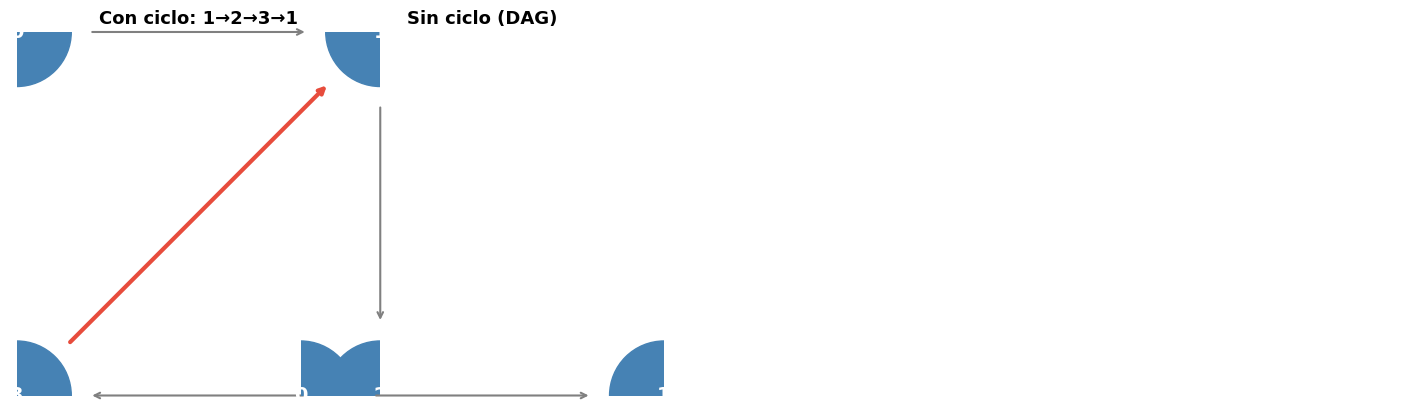

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def detect_cycle_directed(graph):
    WHITE, GRAY, BLACK = 0, 1, 2
    color = {v: WHITE for v in graph}
    cycle_edges = []

    def dfs(v):
        color[v] = GRAY
        for u in graph[v]:
            if color[u] == GRAY:
                cycle_edges.append((v, u))
                return True
            if color[u] == WHITE and dfs(u):
                return True
        color[v] = BLACK
        return False

    has_cycle = any(dfs(v) for v in graph if color[v] == WHITE)
    return has_cycle, cycle_edges

# Graph WITH cycle
cyclic = {0: [1], 1: [2], 2: [3], 3: [1]}  # 1→2→3→1
# Graph WITHOUT cycle (DAG)
acyclic = {0: [1], 1: [2], 2: [3], 3: []}

has1, edges1 = detect_cycle_directed(cyclic)
has2, edges2 = detect_cycle_directed(acyclic)

print(f'Grafo cíclico  {dict(cyclic)}: ciclo={has1}, arista de retroceso: {edges1}')
print(f'Grafo acíclico {dict(acyclic)}: ciclo={has2}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def draw_directed(ax, graph, title, pos, cycle_edge=None):
    for u in graph:
        for v in graph[u]:
            x1, y1 = pos[u]; x2, y2 = pos[v]
            dx, dy = x2-x1, y2-y1
            l = np.sqrt(dx**2+dy**2)
            shrink = 0.2
            is_cycle = cycle_edge and (u,v) in cycle_edge
            color = '#E74C3C' if is_cycle else 'gray'
            lw = 3 if is_cycle else 1.5
            ax.annotate('', xy=(x2-dx*shrink/l, y2-dy*shrink/l),
                       xytext=(x1+dx*shrink/l, y1+dy*shrink/l),
                       arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    for node, (x, y) in pos.items():
        circle = plt.Circle((x, y), 0.15, color='steelblue', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, str(node), ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

pos_c = {0:(0,1), 1:(1,1), 2:(1,0), 3:(0,0)}
draw_directed(axes[0], cyclic, 'Con ciclo: 1→2→3→1', pos_c, edges1)

pos_a = {0:(0,0), 1:(1,0), 2:(2,0), 3:(3,0)}
draw_directed(axes[1], acyclic, 'Sin ciclo (DAG)', pos_a)

plt.tight_layout()
plt.show()

## Componentes Conexas

Una **componente conexa** es un subgrafo maximal donde existe un camino entre todo par de vértices.

### Algoritmo

Ejecutar BFS/DFS desde cada nodo no visitado. Cada ejecución encuentra una componente.

### Complejidad: $O(V + E)$

### Para grafos dirigidos: Componentes Fuertemente Conexas

En un dígrafo, una **SCC** (Strongly Connected Component) es un subgrafo maximal donde existe un camino dirigido entre todo par.

Algoritmos: **Tarjan** ($O(V+E)$), **Kosaraju** ($O(V+E)$)

Componentes conexas (4):
  Componente 1: [0, 1, 2]
  Componente 2: [3, 4, 5]
  Componente 3: [6, 7]
  Componente 4: [8]


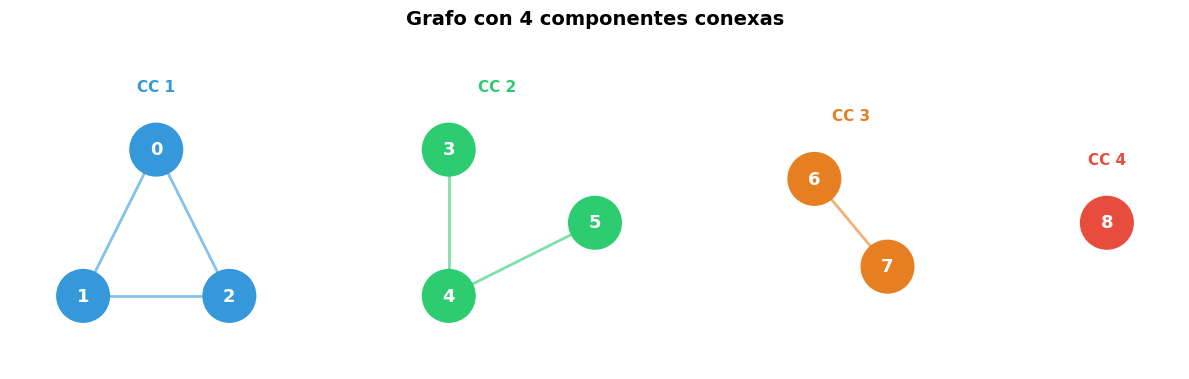

In [12]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

def find_components(graph):
    visited = set()
    components = []

    for start in graph:
        if start in visited:
            continue
        # BFS for this component
        component = []
        queue = deque([start])
        visited.add(start)
        while queue:
            v = queue.popleft()
            component.append(v)
            for u in graph[v]:
                if u not in visited:
                    visited.add(u)
                    queue.append(u)
        components.append(component)
    return components

# Graph with 3 components
disconnected = {
    0: [1, 2], 1: [0, 2], 2: [0, 1],       # Component 1
    3: [4], 4: [3, 5], 5: [4],               # Component 2
    6: [7], 7: [6],                           # Component 3
    8: []                                      # Component 4 (isolated)
}

components = find_components(disconnected)
print(f'Componentes conexas ({len(components)}):')
for i, comp in enumerate(components):
    print(f'  Componente {i+1}: {comp}')

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
comp_pos = {
    0:(0.5,1), 1:(0,0), 2:(1,0),
    3:(2.5,1), 4:(2.5,0), 5:(3.5,0.5),
    6:(5,0.8), 7:(5.5,0.2),
    8:(7, 0.5)
}
comp_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']
node_to_comp = {}
for i, comp in enumerate(components):
    for node in comp:
        node_to_comp[node] = i

for u in disconnected:
    for v in disconnected[u]:
        if v > u:
            x1, y1 = comp_pos[u]; x2, y2 = comp_pos[v]
            ax.plot([x1,x2], [y1,y2], color=comp_colors[node_to_comp[u]], linewidth=2, alpha=0.6)

for node, (x, y) in comp_pos.items():
    color = comp_colors[node_to_comp[node]]
    circle = plt.Circle((x, y), 0.18, color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, str(node), ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=4)

# Labels
for i, comp in enumerate(components):
    xs = [comp_pos[n][0] for n in comp]
    ys = [comp_pos[n][1] for n in comp]
    cx, cy = np.mean(xs), max(ys) + 0.4
    ax.text(cx, cy, f'CC {i+1}', ha='center', fontsize=11, fontweight='bold', color=comp_colors[i])

ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 1.8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Grafo con {len(components)} componentes conexas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Floyd-Warshall — Caminos más cortos entre todos los pares

### Algoritmo

```
función FloydWarshall(matriz_adyacencia):
    dist = copia(matriz_adyacencia)  // dist[i][j] = peso de i a j

    para k = 0 hasta |V|-1:           // nodo intermedio
        para i = 0 hasta |V|-1:       // origen
            para j = 0 hasta |V|-1:   // destino
                si dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]

    retornar dist
```

### Idea: programación dinámica

$$d_{ij}^{(k)} = \min\left(d_{ij}^{(k-1)},\; d_{ik}^{(k-1)} + d_{kj}^{(k-1)}\right)$$

"¿Es mejor ir de $i$ a $j$ directamente, o pasando por $k$?"

### Complejidad: $O(V^3)$ tiempo, $O(V^2)$ espacio

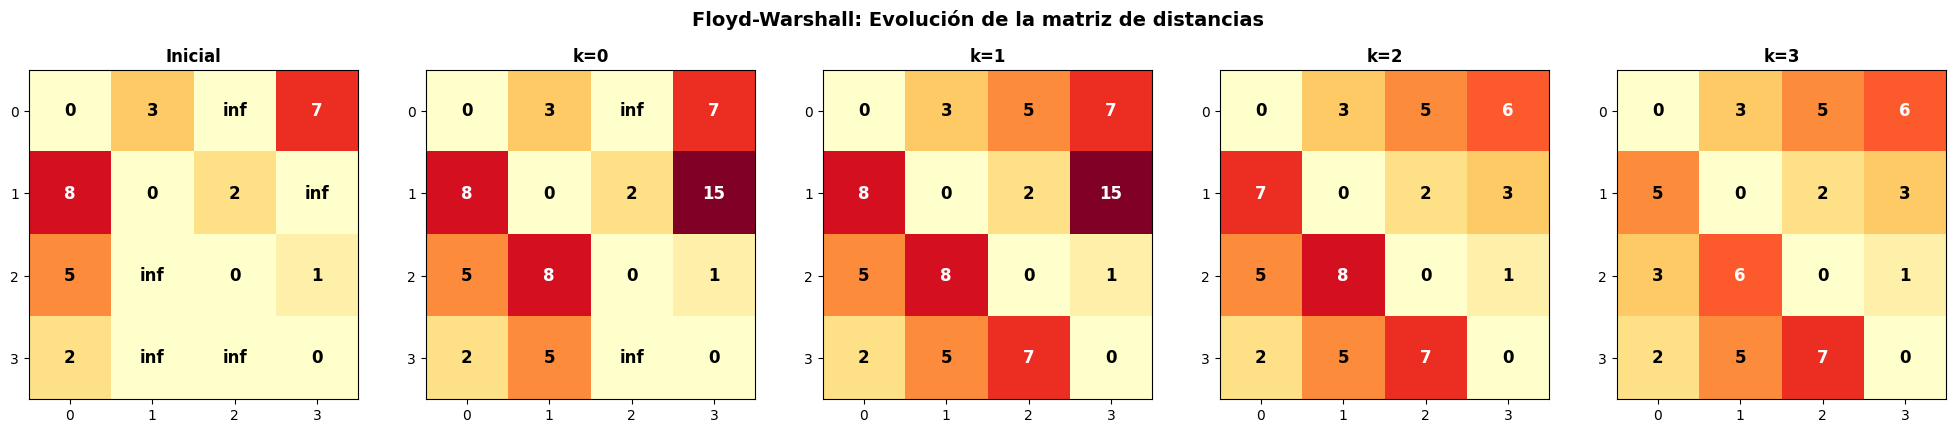

Matriz de distancias mínimas:
[0, 3, 5, 6]
[5, 0, 2, 3]
[3, 6, 0, 1]
[2, 5, 7, 0]


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def floyd_warshall(adj_matrix):
    n = len(adj_matrix)
    dist = np.array(adj_matrix, dtype=float)
    iterations = [dist.copy()]

    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
        iterations.append(dist.copy())

    return dist, iterations

# Create adjacency matrix
INF = float('inf')
adj = [
    [0,   3,   INF, 7  ],
    [8,   0,   2,   INF],
    [5,   INF, 0,   1  ],
    [2,   INF, INF, 0  ]
]

result, iters = floyd_warshall(adj)

# Visualize iterations
fig, axes = plt.subplots(1, len(iters), figsize=(4*len(iters), 4))
if len(iters) == 1:
    axes = [axes]

for idx, (ax, mat) in enumerate(zip(axes, iters)):
    display = np.where(mat == INF, -1, mat)
    im = ax.imshow(display, cmap='YlOrRd', vmin=0, vmax=10)
    for i in range(4):
        for j in range(4):
            val = mat[i][j]
            text = str(int(val)) if val != INF else 'inf'
            color = 'white' if val > 5 and val != INF else 'black'
            ax.text(j, i, text, ha='center', va='center', fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    title = 'Inicial' if idx == 0 else f'k={idx-1}'
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Floyd-Warshall: Evolución de la matriz de distancias', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Matriz de distancias mínimas:')
for row in result:
    print([int(x) if x != INF else 'inf' for x in row])

## Grafos Bipartitos

Un grafo es **bipartito** si se puede colorear con 2 colores sin que dos nodos adyacentes tengan el mismo color.

### Algoritmo (BFS con coloreo)

```
función es_bipartito(grafo):
    color = {}
    para cada nodo v no coloreado:
        color[v] = 0
        cola = [v]
        mientras cola no esté vacía:
            u = cola.popleft()
            para cada vecino w de u:
                si w no está coloreado:
                    color[w] = 1 - color[u]
                    cola.agregar(w)
                si no, si color[w] == color[u]:
                    retornar FALSO
    retornar VERDADERO
```

### Complejidad: $O(V + E)$

### Aplicaciones
- Matching (asignación de tareas)
- Scheduling
- Verificar si un grafo es 2-coloreable

Grafo 1 bipartito: True, colores: {0: 0, 3: 1, 4: 1, 1: 0, 2: 0, 5: 1}
Grafo 2 bipartito: False


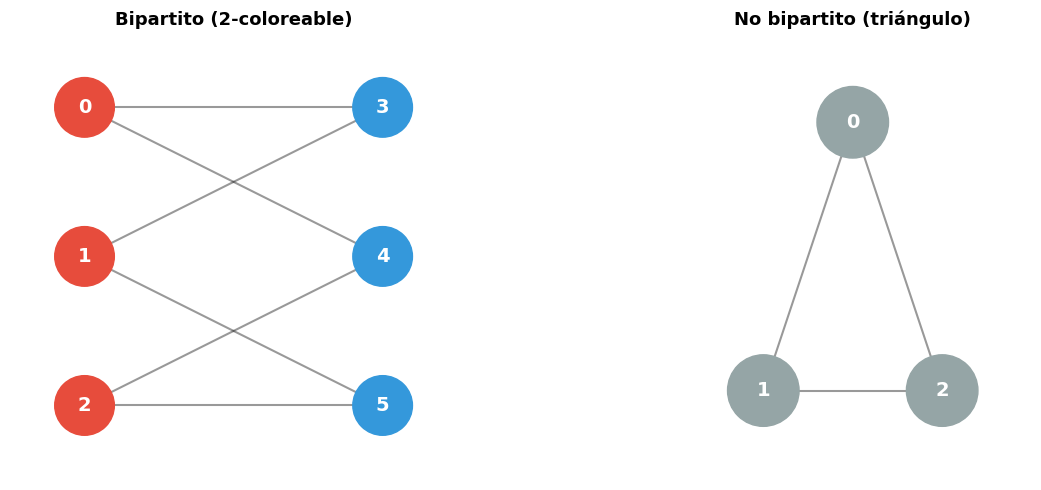

In [14]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

def is_bipartite(graph):
    color = {}
    for start in graph:
        if start in color:
            continue
        color[start] = 0
        queue = deque([start])
        while queue:
            u = queue.popleft()
            for w in graph[u]:
                if w not in color:
                    color[w] = 1 - color[u]
                    queue.append(w)
                elif color[w] == color[u]:
                    return False, color
    return True, color

# Bipartite graph
bipartite_g = {0:[3,4], 1:[3,5], 2:[4,5], 3:[0,1], 4:[0,2], 5:[1,2]}
# Non-bipartite (triangle)
non_bipartite_g = {0:[1,2], 1:[0,2], 2:[0,1]}

res1, col1 = is_bipartite(bipartite_g)
res2, col2 = is_bipartite(non_bipartite_g)

print(f'Grafo 1 bipartito: {res1}, colores: {col1}')
print(f'Grafo 2 bipartito: {res2}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bipartite
pos1 = {0:(0,2), 1:(0,1), 2:(0,0), 3:(2,2), 4:(2,1), 5:(2,0)}
color_map = {0: '#E74C3C', 1: '#3498DB'}
for u in bipartite_g:
    for v in bipartite_g[u]:
        if v > u:
            x1,y1 = pos1[u]; x2,y2 = pos1[v]
            axes[0].plot([x1,x2],[y1,y2], 'k-', linewidth=1.5, alpha=0.4)
for node, (x,y) in pos1.items():
    c = color_map[col1[node]]
    circle = plt.Circle((x,y), 0.2, color=c, zorder=3)
    axes[0].add_patch(circle)
    axes[0].text(x, y, str(node), ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
axes[0].set_xlim(-0.5, 2.5); axes[0].set_ylim(-0.5, 2.5)
axes[0].set_aspect('equal'); axes[0].axis('off')
axes[0].set_title('Bipartito (2-coloreable)', fontsize=13, fontweight='bold')

# Non-bipartite
pos2 = {0:(0.5, 1.5), 1:(0, 0), 2:(1, 0)}
for u in non_bipartite_g:
    for v in non_bipartite_g[u]:
        if v > u:
            x1,y1 = pos2[u]; x2,y2 = pos2[v]
            axes[1].plot([x1,x2],[y1,y2], 'k-', linewidth=1.5, alpha=0.4)
for node, (x,y) in pos2.items():
    circle = plt.Circle((x,y), 0.2, color='#95A5A6', zorder=3)
    axes[1].add_patch(circle)
    axes[1].text(x, y, str(node), ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 2)
axes[1].set_aspect('equal'); axes[1].axis('off')
axes[1].set_title('No bipartito (triángulo)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Implementaciones completas

In [15]:
from collections import deque
import heapq

# ==================== REPRESENTACIONES ====================

class Graph:
    def __init__(self, directed=False):
        self.adj = {}  # adjacency list
        self.directed = directed

    def add_edge(self, u, v, weight=1):
        self.adj.setdefault(u, []).append((v, weight))
        if not self.directed:
            self.adj.setdefault(v, []).append((u, weight))
        else:
            self.adj.setdefault(v, [])  # ensure v exists

    def neighbors(self, v):
        return self.adj.get(v, [])

    def vertices(self):
        return list(self.adj.keys())

# ==================== BFS ====================

def bfs(graph, start):
    visited = {start}
    queue = deque([start])
    order = []
    while queue:
        v = queue.popleft()
        order.append(v)
        for u, _ in graph.neighbors(v):
            if u not in visited:
                visited.add(u)
                queue.append(u)
    return order

# ==================== DFS ====================

def dfs(graph, start):
    visited = set()
    stack = [start]
    order = []
    while stack:
        v = stack.pop()
        if v in visited:
            continue
        visited.add(v)
        order.append(v)
        for u, _ in reversed(graph.neighbors(v)):
            if u not in visited:
                stack.append(u)
    return order

# ==================== DIJKSTRA ====================

def dijkstra(graph, start):
    dist = {v: float('inf') for v in graph.vertices()}
    dist[start] = 0
    prev = {}
    heap = [(0, start)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:
            continue
        for v, w in graph.neighbors(u):
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                heapq.heappush(heap, (dist[v], v))
    return dist, prev

def shortest_path(prev, target):
    path = []
    v = target
    while v in prev:
        path.append(v)
        v = prev[v]
    path.append(v)
    return list(reversed(path))

# ==================== BELLMAN-FORD ====================

def bellman_ford(graph, start):
    vertices = graph.vertices()
    dist = {v: float('inf') for v in vertices}
    dist[start] = 0
    for _ in range(len(vertices) - 1):
        for u in vertices:
            for v, w in graph.neighbors(u):
                if dist[u] + w < dist[v]:
                    dist[v] = dist[u] + w
    # Negative cycle check
    for u in vertices:
        for v, w in graph.neighbors(u):
            if dist[u] + w < dist[v]:
                return None  # negative cycle
    return dist

# ==================== KRUSKAL ====================

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return False
        if self.rank[rx] < self.rank[ry]: rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]: self.rank[rx] += 1
        return True

def kruskal(n_vertices, edges):
    sorted_e = sorted(edges, key=lambda x: x[2])
    uf = UnionFind(n_vertices)
    mst = []
    for u, v, w in sorted_e:
        if uf.union(u, v):
            mst.append((u, v, w))
        if len(mst) == n_vertices - 1:
            break
    return mst

# ==================== PRIM ====================

def prim(graph, start=None):
    if start is None:
        start = graph.vertices()[0]
    in_mst = {start}
    mst = []
    heap = [(w, start, v) for v, w in graph.neighbors(start)]
    heapq.heapify(heap)
    while heap and len(in_mst) < len(graph.vertices()):
        w, u, v = heapq.heappop(heap)
        if v in in_mst: continue
        in_mst.add(v)
        mst.append((u, v, w))
        for nb, wt in graph.neighbors(v):
            if nb not in in_mst:
                heapq.heappush(heap, (wt, v, nb))
    return mst

# ==================== TOPOLOGICAL SORT ====================

def topological_sort(graph):
    in_deg = {v: 0 for v in graph.vertices()}
    for v in graph.vertices():
        for u, _ in graph.neighbors(v):
            in_deg[u] += 1
    queue = deque([v for v in in_deg if in_deg[v] == 0])
    order = []
    while queue:
        v = queue.popleft()
        order.append(v)
        for u, _ in graph.neighbors(v):
            in_deg[u] -= 1
            if in_deg[u] == 0:
                queue.append(u)
    return order if len(order) == len(graph.vertices()) else None

# ==================== DEMO ====================

g = Graph()
for u, v, w in [(0,1,4),(0,2,1),(1,2,2),(1,3,5),(2,3,8),(3,4,3)]:
    g.add_edge(u, v, w)

print('BFS desde 0:', bfs(g, 0))
print('DFS desde 0:', dfs(g, 0))

dist, prev = dijkstra(g, 0)
print(f'Dijkstra desde 0: distancias={dist}')
print(f'Camino 0→4: {shortest_path(prev, 4)}')

mst = kruskal(5, [(0,1,4),(0,2,1),(1,2,2),(1,3,5),(2,3,8),(3,4,3)])
print(f'Kruskal MST: {mst} (peso={sum(w for _,_,w in mst)})')

BFS desde 0: [0, 1, 2, 3, 4]
DFS desde 0: [0, 1, 2, 3, 4]
Dijkstra desde 0: distancias={0: 0, 1: 3, 2: 1, 3: 8, 4: 11}
Camino 0→4: [0, 2, 1, 3, 4]
Kruskal MST: [(0, 2, 1), (1, 2, 2), (3, 4, 3), (1, 3, 5)] (peso=11)


## Resumen de algoritmos de grafos

| Algoritmo | Problema | Tiempo | Espacio | Notas |
|-----------|----------|--------|---------|-------|
| **BFS** | Recorrido / Camino más corto (no pond.) | $O(V+E)$ | $O(V)$ | Cola FIFO |
| **DFS** | Recorrido / Detección ciclos | $O(V+E)$ | $O(V)$ | Pila/recursión |
| **Dijkstra** | Camino más corto (pesos $\geq 0$) | $O((V+E)\log V)$ | $O(V)$ | Min-heap |
| **Bellman-Ford** | Camino más corto (pesos negativos) | $O(VE)$ | $O(V)$ | Detecta ciclos negativos |
| **Floyd-Warshall** | Todos los pares más cortos | $O(V^3)$ | $O(V^2)$ | Programación dinámica |
| **Kruskal** | MST | $O(E \log E)$ | $O(V)$ | Union-Find |
| **Prim** | MST | $O((V+E)\log V)$ | $O(V)$ | Min-heap |
| **Kahn** | Orden topológico | $O(V+E)$ | $O(V)$ | Solo DAGs |
| **Tarjan** | SCC | $O(V+E)$ | $O(V)$ | Componentes fuertes |

### Guía rápida: ¿Qué algoritmo usar?

```
¿Necesitas camino más corto?
├── ¿Grafo no ponderado? → BFS
├── ¿Todos los pesos ≥ 0? → Dijkstra
├── ¿Pesos negativos? → Bellman-Ford
└── ¿Todos los pares? → Floyd-Warshall

¿Necesitas un árbol de expansión mínima?
├── ¿Grafo disperso? → Kruskal
└── ¿Grafo denso? → Prim

¿Necesitas ordenar dependencias?
└── Orden topológico (Kahn / DFS)

¿Necesitas detectar ciclos?
├── ¿Grafo dirigido? → DFS con colores
└── ¿Grafo no dirigido? → DFS / Union-Find
```